In [2]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_column",None)
pd.set_option("display.width",1000)

In [3]:
sales = pd.read_excel("eletronic_sales.xlsx")
sales.head(200)
sales.describe()

,Date,Units,Price
count,43,43.000000,43.000000
mean,2014-12-29 00:00:00,49.325581,20.308605
min,2014-01-06 00:00:00,2.000000,1.290000
25%,2014-07-03 12:00:00,27.500000,3.990000
50%,2014-12-29 00:00:00,53.000000,4.990000
75%,2015-06-25 12:00:00,74.500000,17.990000
max,2015-12-21 00:00:00,96.000000,275.000000
std,NaN,30.078248,47.345118


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         43 non-null     datetime64[ns]
 1   Branch       43 non-null     object        
 2   Sales Agent  43 non-null     object        
 3   Products     43 non-null     object        
 4   Units        43 non-null     int64         
 5   Price        43 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 2.1+ KB


In [5]:
sales["Revenue"]=  sales["Units"] * sales["Price"]
sales.head()

,Date,Branch,Sales Agent,Products,Units,Price,Revenue
0,2014-09-01,Woji,Chinedu,Apple,2,125.00,250.00
1,2015-06-17,Woji,Emeka,Apple,5,125.00,625.00
2,2015-09-10,Woji,Ibrahim,Lenovo,7,1.29,9.03
3,2015-11-17,Woji,Tolu,HP,11,4.99,54.89
4,2015-10-31,Woji,Tonye,Lenovo,14,1.29,18.06


In [6]:
sales.sort_values(by="Sales Agent")

,Date,Branch,Sales Agent,Products,Units,Price,Revenue
29,2014-04-01,GRA,Blessing,HP,60,4.99,299.40
24,2015-02-18,GRA,Blessing,HP,4,4.99,19.96
35,2014-01-06,GRA,Blessing,Lenovo,95,1.99,189.05
26,2014-09-18,GRA,Blessing,Dell,16,15.99,255.84
28,2014-08-15,GRA,Blessing,Lenovo,35,4.99,174.65
32,2014-10-22,GRA,Blessing,Compaq,64,8.99,575.36
31,2015-07-04,GRA,Blessing,Dell,62,4.99,309.38
30,2014-06-08,GRA,Blessing,HP,60,8.99,539.40
0,2014-09-01,Woji,Chinedu,Apple,2,125.00,250.00
16,2014-12-12,Woji,Chinedu,Lenovo,67,1.29,86.43


In [7]:
sales["Sales Agent"].unique()

array(['Chinedu', 'Emeka', 'Ibrahim', 'Tolu', 'Tonye', 'George',
       'Blessing', 'Chioma', 'Torbari', 'Uche', 'Tunde'], dtype=object)

In [8]:
sales["Sales Agent"].nunique()

11

In [9]:
sales.groupby("Branch")["Sales Agent"].count()

Branch
GRA     13
Town     6
Woji    24
Name: Sales Agent, dtype: int64

In [10]:
Total_revenue_by_branch=sales.groupby("Branch")["Revenue"].sum().sort_values(ascending=False)
Total_revenue_by_branch

Branch
Woji    11139.07
GRA      6002.09
Town     2486.72
Name: Revenue, dtype: float64

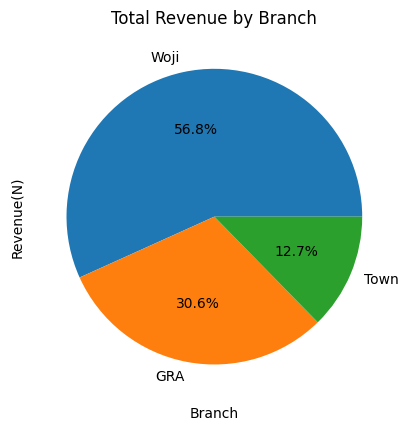

In [11]:
plt.pie(Total_revenue_by_branch.values, labels=Total_revenue_by_branch.index, autopct='%1.1f%%')
plt.xlabel("Branch")
plt.ylabel("Revenue(N)")
plt.title("Total Revenue by Branch")
plt.show()

In [12]:
sales.groupby("Branch").agg({'Revenue':'max'})

,Revenue
Branch,
GRA,1619.19
Town,1139.43
Woji,1879.06


In [13]:
sales.groupby("Sales Agent").agg({'Revenue':'sum'})

,Revenue
Sales Agent,
Blessing,2363.04
Chinedu,1641.43
Chioma,3102.30
Emeka,3109.44
George,1387.77
Ibrahim,1749.87
Tolu,2812.19
Tonye,438.37
Torbari,536.75


In [14]:
x=sales.groupby("Sales Agent").agg({'Revenue':'mean'})

In [15]:
sales["Units"].mean()

np.float64(49.325581395348834)

In [16]:
sales["Revenue"].mean()

np.float64(456.4623255813953)

In [17]:
sales["Revenue"].max()

np.float64(1879.06)

In [18]:
sales["Revenue"].min()

np.float64(9.030000000000001)

In [19]:
sales.groupby("Sales Agent").agg({'Units':'std', 'Revenue':'std',})

,Units,Revenue
Sales Agent,,
Blessing,29.423023,185.721801
Chinedu,44.440972,661.399147
Chioma,36.253735,672.198660
Emeka,37.384266,266.948874
George,31.085902,217.928367
Ibrahim,27.519084,304.925991
Tolu,35.569650,749.734697
Tonye,29.375443,61.458755
Torbari,47.376154,297.925300


new insight

In [20]:
#lets convert the date column to datetime
sales["Date"]= pd.to_datetime(sales["Date"])

In [21]:
sales.dtypes

Date           datetime64[ns]
Branch                 object
Sales Agent            object
Products               object
Units                   int64
Price                 float64
Revenue               float64
dtype: object

<Axes: xlabel='Data Types', ylabel='Count'>

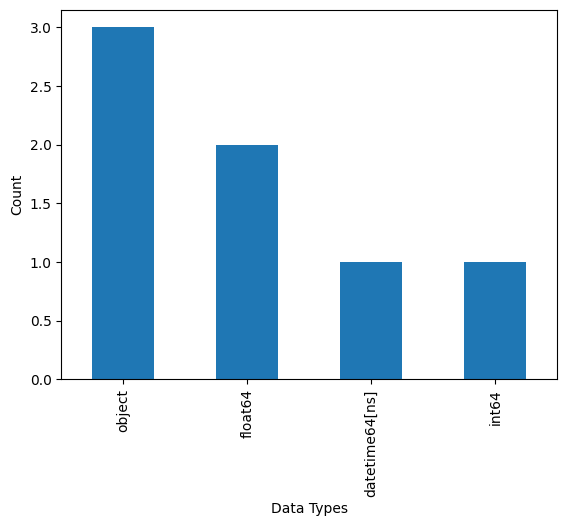

In [22]:
#this is checking the columns with there respective data type
sales.dtypes.value_counts().plot(kind="bar",xlabel = "Data Types", ylabel = "Count")

In [23]:
sales["Year"] =sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month_name()
sales["Week"] =sales["Date"].dt.day_name()


In [24]:
sales.head()

,Date,Branch,Sales Agent,Products,Units,Price,Revenue,Year,Month,Week
0,2014-09-01,Woji,Chinedu,Apple,2,125.00,250.00,2014,September,Monday
1,2015-06-17,Woji,Emeka,Apple,5,125.00,625.00,2015,June,Wednesday
2,2015-09-10,Woji,Ibrahim,Lenovo,7,1.29,9.03,2015,September,Thursday
3,2015-11-17,Woji,Tolu,HP,11,4.99,54.89,2015,November,Tuesday
4,2015-10-31,Woji,Tonye,Lenovo,14,1.29,18.06,2015,October,Saturday


In [25]:
sales["Products"].nunique()

5

In [26]:
sales["Sales Agent"].nunique()

11

In [27]:
#This changes the file .The date colunm is removed and now in index position
sales.set_index("Date", inplace =True)

In [28]:
sales.head()

,Branch,Sales Agent,Products,Units,Price,Revenue,Year,Month,Week
Date,,,,,,,,,
2014-09-01,Woji,Chinedu,Apple,2,125.00,250.00,2014,September,Monday
2015-06-17,Woji,Emeka,Apple,5,125.00,625.00,2015,June,Wednesday
2015-09-10,Woji,Ibrahim,Lenovo,7,1.29,9.03,2015,September,Thursday
2015-11-17,Woji,Tolu,HP,11,4.99,54.89,2015,November,Tuesday
2015-10-31,Woji,Tonye,Lenovo,14,1.29,18.06,2015,October,Saturday


In [29]:
sales["Year"].unique()

array([2014, 2015], dtype=int32)

In [30]:
sales2014= sales[sales["Year"]==2014]
sales2014.head(3)

,Branch,Sales Agent,Products,Units,Price,Revenue,Year,Month,Week
Date,,,,,,,,,
2014-09-01,Woji,Chinedu,Apple,2,125.00,250.00,2014,September,Monday
2014-02-26,Woji,Ibrahim,Compaq,27,19.99,539.73,2014,February,Wednesday
2014-10-05,Woji,George,HP,28,8.99,251.72,2014,October,Sunday


In [31]:
sales2015= sales[sales["Year"]==2015]
sales2015.head(2)

,Branch,Sales Agent,Products,Units,Price,Revenue,Year,Month,Week
Date,,,,,,,,,
2015-06-17,Woji,Emeka,Apple,5,125.00,625.00,2015,June,Wednesday
2015-09-10,Woji,Ibrahim,Lenovo,7,1.29,9.03,2015,September,Thursday


Generating insights from the yearly data

In [32]:
#total yearly sales
Total_yearly_sales14 = sales2014.groupby("Year")["Revenue"].sum().sort_index()
Total_yearly_sales14

Year
2014    9258.34
Name: Revenue, dtype: float64

In [33]:
Total_yearly_sales15 = sales2015.groupby("Year")["Revenue"].sum().sort_index()
Total_yearly_sales15

Year
2015    10369.54
Name: Revenue, dtype: float64

In [34]:
#now lets generate for monthly sales
Total_monthly_sales14 = sales2014.groupby("Month")["Revenue"].sum()
Total_monthly_sales14

Month
April         448.65
August        174.65
December     1269.69
February      719.37
January      1188.55
July         1676.90
June          988.50
March         167.44
May           512.78
November      778.89
October       827.08
September     505.84
Name: Revenue, dtype: float64

In [35]:
#2015 monthly sales
Total_monthly_sales15 = sales2015.groupby("Month")["Revenue"].sum().sort_index()
Total_monthly_sales15

Month
April         610.38
August       1830.90
December     2018.78
February     1324.96
January       413.54
July          996.33
June          625.00
March         389.43
May           787.57
November       54.89
October      1157.49
September     160.27
Name: Revenue, dtype: float64

<Axes: xlabel='Day of the week', ylabel='Revenue(N)'>

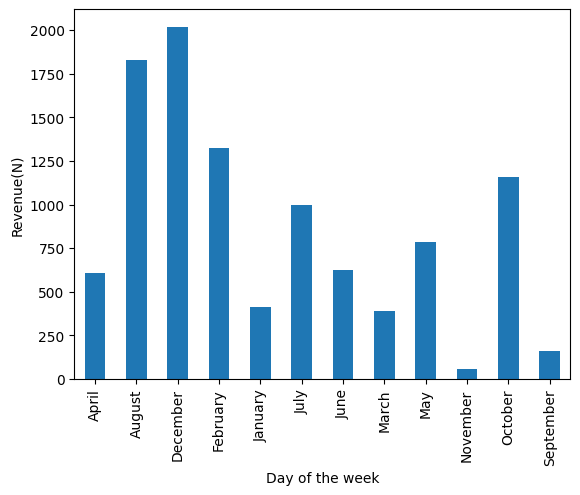

In [36]:
# lets put this in a plot using pandas
Total_monthly_sales15.plot(kind = "bar",xlabel = "Day of the week", ylabel ="Revenue(N)")

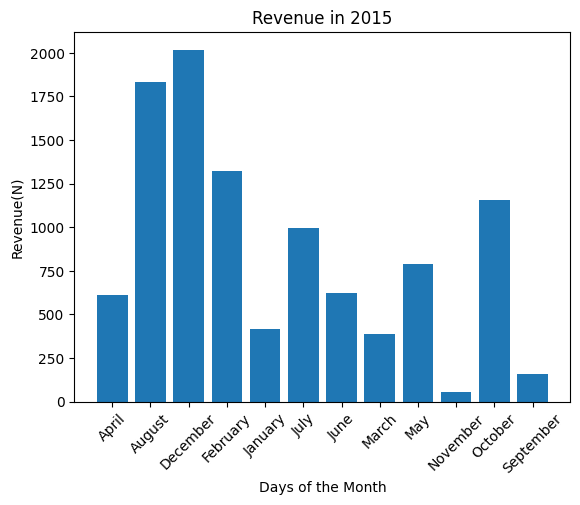

In [37]:
plt.bar(Total_monthly_sales15.index,Total_monthly_sales15.values)
plt.xlabel("Days of the Month")
plt.ylabel("Revenue(N)")
plt.title("Revenue in 2015")
plt.xticks(rotation=45)
plt.show()

In [38]:
Total_revenue_by_product = sales.groupby("Products")["Revenue"].sum().sort_values(ascending = False)
Total_revenue_by_product

Products
HP        9577.65
Dell      4169.87
Lenovo    2135.14
Compaq    2045.22
Apple     1700.00
Name: Revenue, dtype: float64

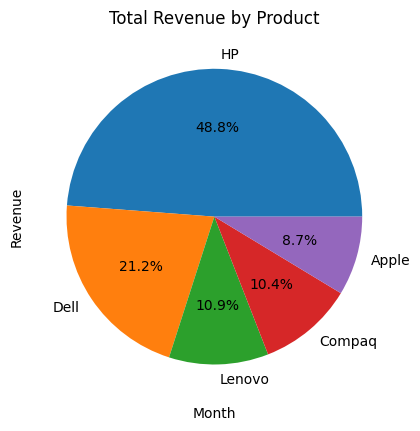

In [39]:
plt.pie(Total_revenue_by_product.values,labels=Total_revenue_by_product.index, autopct='%1.1f%%')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Total Revenue by Product")
plt.show()

In [40]:
#6. Trends of sales
Trends_of_sales_over_the_year = sales.groupby(["Year","Month"])["Revenue"].sum().reset_index()
Trends_of_sales_over_the_year

,Year,Month,Revenue
0,2014,April,448.65
1,2014,August,174.65
2,2014,December,1269.69
3,2014,February,719.37
4,2014,January,1188.55
5,2014,July,1676.90
6,2014,June,988.50
7,2014,March,167.44
8,2014,May,512.78
9,2014,November,778.89


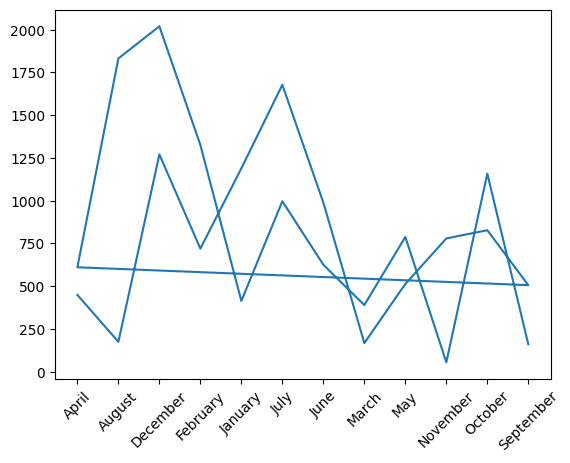

In [49]:
# lets plot
plt.plot(Trends_of_sales_over_the_year["Month"],Trends_of_sales_over_the_year["Revenue"])
plt.xticks(rotation=45)
plt.show()